In [13]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [14]:
def normalize_to_grayscale(
    imgs: np.ndarray,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Normalize images to [-1, 1] and return grayscale.

    Parameters
    ----------
    imgs : np.ndarray
        Input images of shape (N,H,W), (N,H,W,1), or (N,H,W,3).
    eps : float
        Small constant to avoid division by zero.

    Returns
    -------
    np.ndarray
        Normalized grayscale images of shape (N,H,W,1), dtype float32.
    """

    imgs = np.asarray(imgs)

    # Ensure channel dimension
    if imgs.ndim == 3:
        imgs = imgs[..., None]  # (N,H,W,1)

    if imgs.ndim != 4:
        raise ValueError(f"Expected (N,H,W[,C]), got {imgs.shape}")

    imgs = imgs.astype(np.float32)

    # Convert RGB → grayscale if needed
    if imgs.shape[-1] == 3:
        # Standard luminance conversion
        r, g, b = imgs[..., 0], imgs[..., 1], imgs[..., 2]
        imgs = 0.299 * r + 0.587 * g + 0.114 * b
        imgs = imgs[..., None]

    elif imgs.shape[-1] != 1:
        raise ValueError(f"Unsupported channel count: {imgs.shape[-1]}")

    # Normalize
    max_val = imgs.max()
    if max_val > 1.0:
        imgs = imgs / (max_val + eps)

    imgs = imgs * 2.0 - 1.0  # [-1,1]

    return imgs

In [15]:
## load hr images("/Users
hr_dir = Path("/Users/christian/Projects/improved-diffusion/data/super_res_test/hr")
hr_images = sorted(list(hr_dir.glob("*.tiff")))

array_hr = []
for img_path in hr_images:
    img = Image.open(img_path)
    array_hr.append(np.array(img))
array_hr = np.stack(array_hr, axis=0)  # shape (N, H, W, C)

array_hr = normalize_to_grayscale(array_hr)
print("HR images shape:", array_hr.shape)
print(array_hr.dtype, array_hr.min(), array_hr.max())

HR images shape: (11, 256, 256, 1)
float32 -0.042253494 1.0


In [16]:
## load lr images
lr_dir = Path("/Users/christian/Projects/improved-diffusion/data/super_res_test/lr_images.npz")

array_lr = np.load(lr_dir)["arr_0"]  # shape (N, H, W, C)
array_lr = normalize_to_grayscale(array_lr)
print("HR images shape:", array_lr.shape)
print(array_lr.dtype, array_lr.min(), array_lr.max())

HR images shape: (11, 64, 64, 1)
float32 0.3538462 1.0


In [17]:
## load sampels from super res model
samp_dir = Path("/Users/christian/Projects/improved-diffusion/results/samples_32x256x256x3.npz")
array_samp = np.load(samp_dir)["arr_0"]  # shape (N, H, W, C)
array_samp = normalize_to_grayscale(array_samp)
print("Sample images shape:", array_samp.shape)
print(array_samp.dtype, array_samp.min(), array_samp.max())

Sample images shape: (32, 256, 256, 1)
float32 -0.7886174 1.0


In [18]:
def mse(a: np.ndarray, b: np.ndarray) -> float:
    """
    Compute mean squared error between two arrays.
    """
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    return np.mean((a - b) ** 2)

def cosine_similarity(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    """
    Compute cosine similarity between two arrays.

    Returns value in [-1, 1].
    """
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    dot = np.dot(a, b)
    norm = np.linalg.norm(a) * np.linalg.norm(b)

    return dot / (norm + eps)

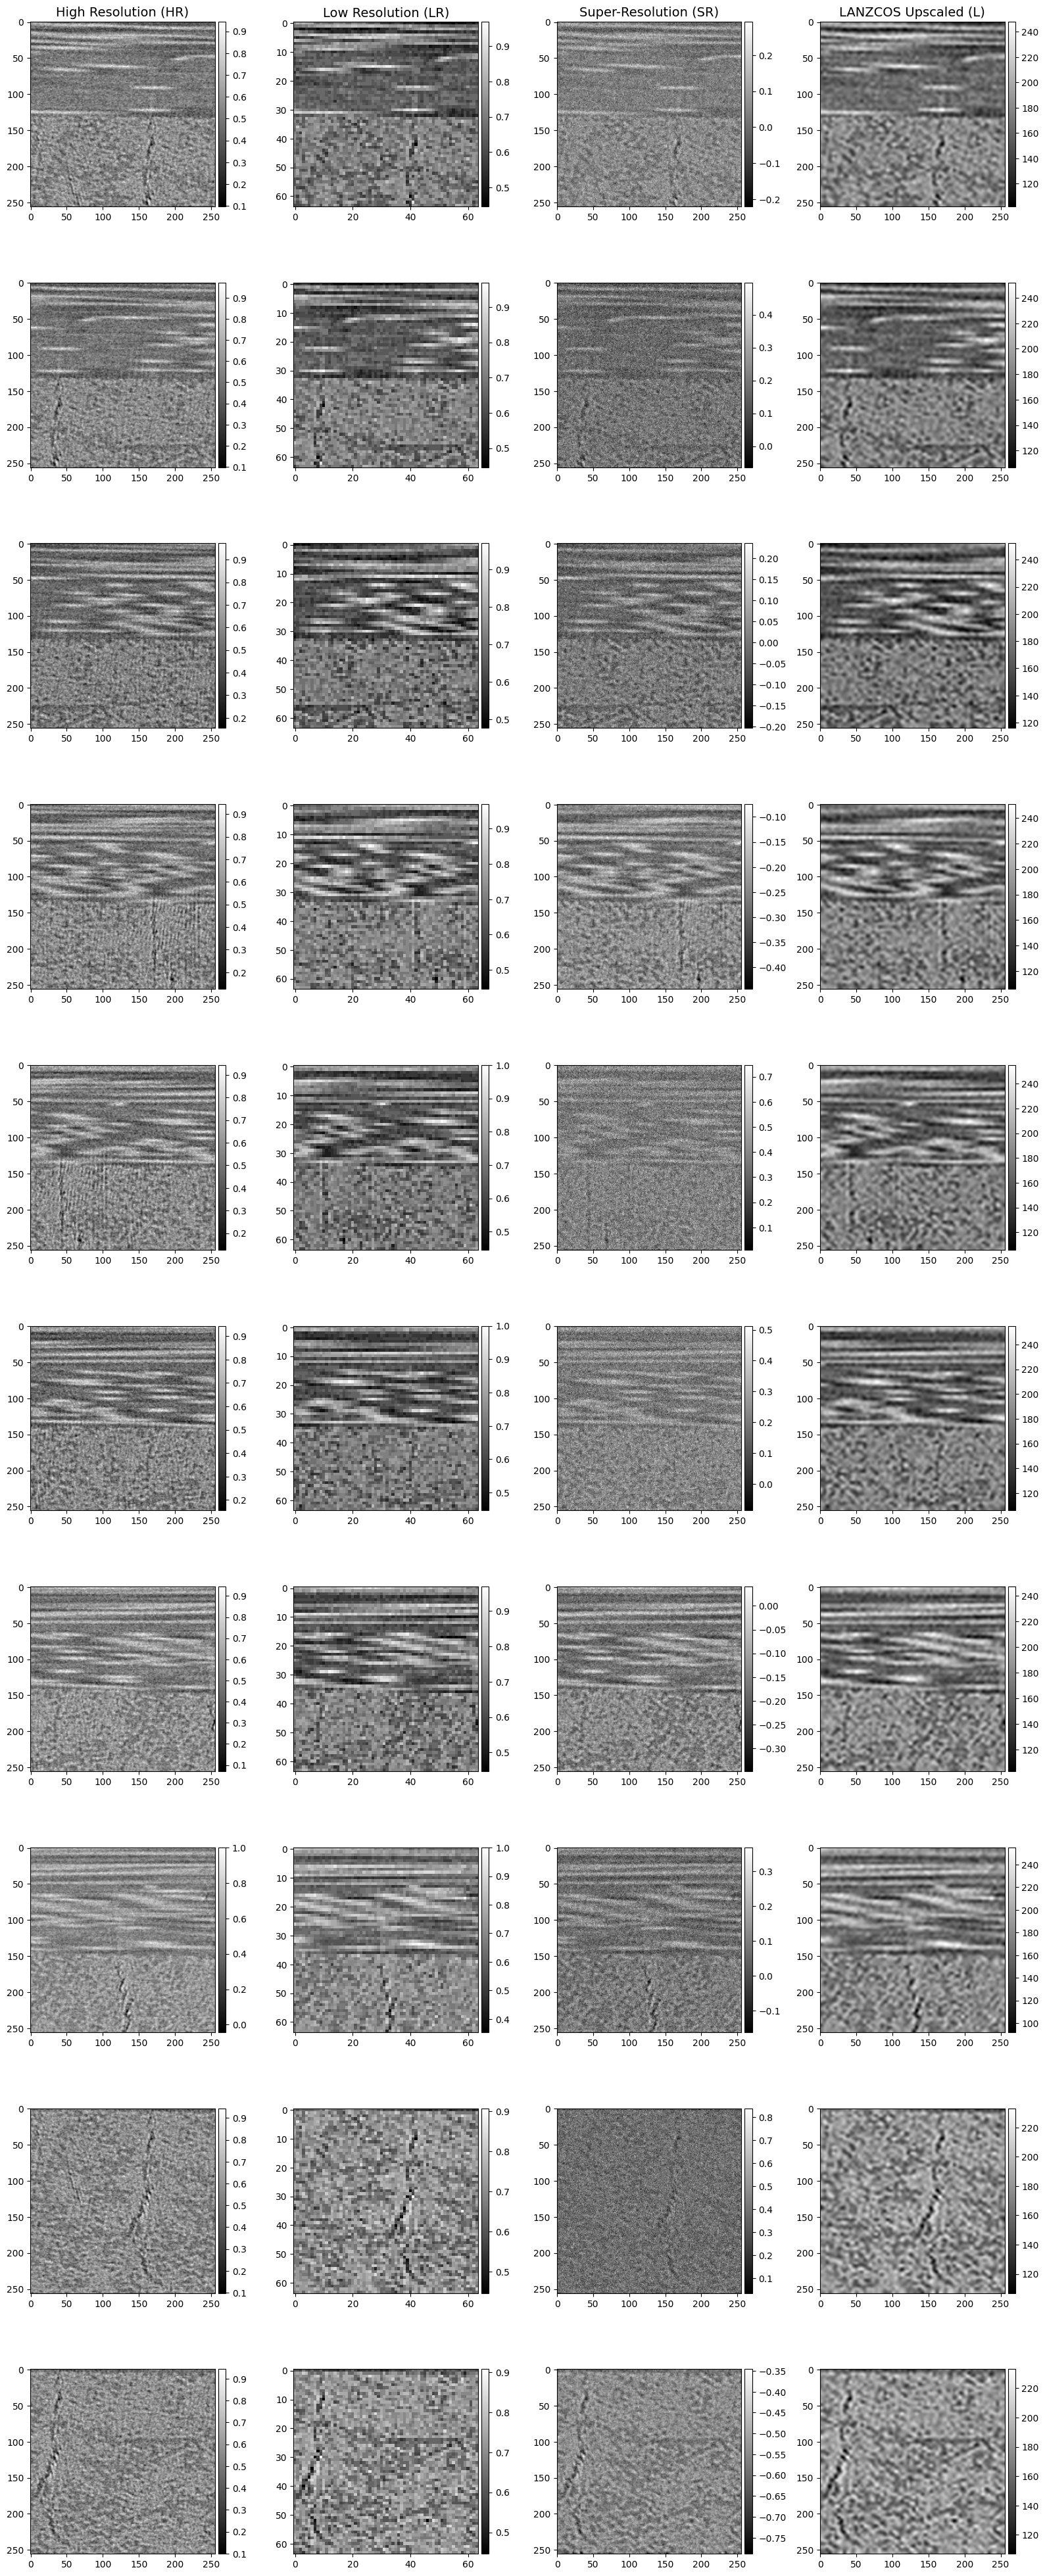

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

n_rows = 10
n_cols = 4

fig, axs = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

# Column titles
col_titles = [
    "High Resolution (HR)",
    "Low Resolution (LR)",
    "Super-Resolution (SR)",
    "LANZCOS Upscaled (L)"
]
for j, title in enumerate(col_titles):
    axs[0, j].set_title(title, fontsize=14)

for idx in range(n_rows):

    # Shared scale for HR / LR / SR
    vmin = min(
        array_hr[idx].min(),
        array_lr[idx].min(),
        array_samp[idx].min()
    )
    vmax = max(
        array_hr[idx].max(),
        array_lr[idx].max(),
        array_samp[idx].max()
    )

    images = []

    # HR
    images.append(
        axs[idx, 0].imshow(array_hr[idx], cmap="gray", 
                        #    vmin=vmin, vmax=vmax
                           )
    )

    # LR
    images.append(
        axs[idx, 1].imshow(array_lr[idx], cmap="gray", 
                        #    vmin=vmin, vmax=vmax
                           )
    )

    # SR
    images.append(
        axs[idx, 2].imshow(array_samp[idx], cmap="gray", 
                        #    vmin=vmin, vmax=vmax
                           )
    )

    # Residual
    # residuals = array_hr[idx] - array_samp[idx]
    # mse_score = mse(array_hr[idx], array_samp[idx])
    # cos_score = cosine_similarity(array_hr[idx], array_samp[idx])
    # images.append(
    #     axs[idx, 3].imshow(residuals, cmap="plasma")
    # )
    # axs[idx, 3].set_title(f"MSE = {mse_score:.2e}\nCos = {cos_score:.2f}", fontsize=10)

    img_scaled = Image.fromarray(array_lr[idx].squeeze() * 255).convert("L").resize(
        (array_hr.shape[2], array_hr.shape[1]), Image.LANCZOS
    )
    images.append(
        axs[idx, 3].imshow(
            np.array(img_scaled), cmap="gray", 
            # vmin=0, vmax=255
        )
    )


    # Remove ticks
  
    # Colorbar for each image
    for j in range(n_cols):
        divider = make_axes_locatable(axs[idx, j])
        cax = divider.append_axes("right", size="4%", pad=0.05)
        fig.colorbar(images[j], cax=cax)

# Apply tight layout AFTER everything is created
fig.tight_layout()
plt.savefig("super_res_comparison.png", dpi=50)
plt.show()


In [20]:
def norm_to_uint8(imgs: np.ndarray) -> np.ndarray:
    """
    Convert images from [-1, 1] float to uint8 [0, 255].

    Parameters
    ----------
    imgs : np.ndarray
        Input array with values in [-1,1].
        Shape: (H,W), (H,W,C), (N,H,W), or (N,H,W,C).

    Returns
    -------
    np.ndarray
        uint8 image array with same shape as input.
    """

    imgs = np.asarray(imgs, dtype=np.float32)

    # Safety clamp
    imgs = np.clip(imgs, -1.0, 1.0)

    # [-1,1] → [0,1]
    imgs = (imgs + 1.0) * 0.5

    # [0,1] → [0,255]
    imgs = (imgs * 255.0).round().astype(np.uint8)

    return imgs

lr_uint8: uint8 184 251 215.944091796875


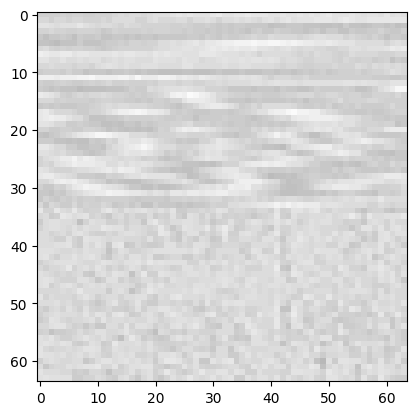

In [21]:
lr_image = norm_to_uint8(array_lr[3,...,0])

print("lr_uint8:", lr_image.dtype, lr_image.min(), lr_image.max(), lr_image.mean())

Image.fromarray(lr_image).save("lr_image.tif")

plt.imshow(lr_image,cmap="gray",vmin=0,vmax=255)

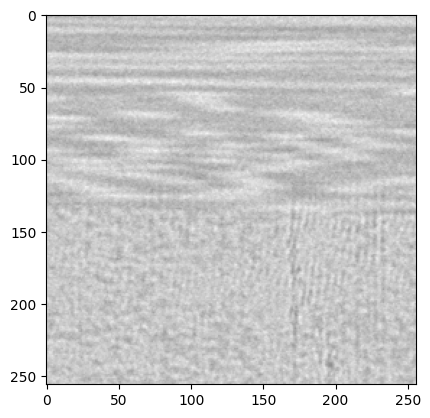

In [22]:
hr_image = norm_to_uint8(array_hr[3,...,0])

Image.fromarray(hr_image).save("hr_image.tif")
plt.imshow(hr_image,cmap="gray",vmin=0,vmax=255)

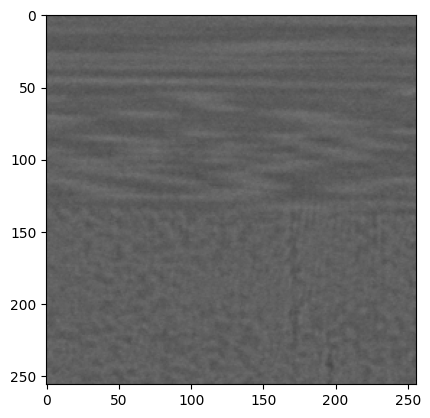

In [23]:
sample_image = norm_to_uint8(array_samp[3,...,0])

Image.fromarray(sample_image).save("sr_image.tif")

plt.imshow(sample_image,cmap="gray",vmin=0,vmax=255)